# Multi-label Clothing Classification
This notebook trains a clothing classifier using FastAI on the [Clothing Dataset Full](https://www.kaggle.com/datasets/agrigorev/clothing-dataset-full/data). It classifies the clothing type (e.g. Shirt, Dress) and whether it's for Kids or Adults.

## 1. Setup — Install & Mount Drive

In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
# Install FastAI
!pip install fastai -q

In [ ]:
# Mount Google Drive (to save/load model)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from fastai.vision.all import *
import pandas as pd
import matplotlib.pyplot as plt

## 2. Download Dataset from Kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"refaatmokhtar","key":"0e9cc78d7af617ac0dc533bf3b522b23"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d agrigorev/clothing-dataset-full
!unzip -q clothing-dataset-full.zip -d /content/clothing-dataset-full
print("Dataset ready!")

Dataset URL: https://www.kaggle.com/datasets/agrigorev/clothing-dataset-full
License(s): CC0-1.0
100% 6.50G/6.50G [01:22<00:00, 84.6MB/s]

Dataset ready!


## 3. Data Cleaning

In [ ]:
# Load labels
labels = pd.read_csv('/content/clothing-dataset-full/images.csv')
labels.head()

,image,sender_id,label,kids
0,4285fab0-751a-4b74-8e9b-43af05deee22,124,Not sure,False
1,ea7b6656-3f84-4eb3-9099-23e623fc1018,148,T-Shirt,False
2,00627a3f-0477-401c-95eb-92642cbe078d,94,Not sure,False
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa,43,T-Shirt,False
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0,189,Shoes,False


In [ ]:
# Classes and their counts
labels['label'].value_counts()

,count
label,
T-Shirt,1011
Longsleeve,699
Pants,692
Shoes,431
Shirt,378
Dress,357
Outwear,312
Shorts,308
Not sure,228


In [ ]:
# Fix: Replace 'Not sure' with 'Not_sure'
labels.loc[labels['label'] == 'Not sure', 'label'] = 'Not_sure'

# Add .jpg suffix to image names
labels['image'] = labels['image'] + '.jpg'

# Fix: Map kids column to meaningful label instead of True/False
labels['kids_label'] = labels['kids'].map({True: 'Kids', False: 'Adults'})
labels['label_cat'] = labels['label'] + ' ' + labels['kids_label']

# Keep only image and label columns
label_df = labels[['image', 'label_cat']]
label_df.head()

,image,label_cat
0,4285fab0-751a-4b74-8e9b-43af05deee22.jpg,Not_sure Adults
1,ea7b6656-3f84-4eb3-9099-23e623fc1018.jpg,T-Shirt Adults
2,00627a3f-0477-401c-95eb-92642cbe078d.jpg,Not_sure Adults
3,ea2ffd4d-9b25-4ca8-9dc2-bd27f1cc59fa.jpg,T-Shirt Adults
4,3b86d877-2b9e-4c8b-a6a2-1d87513309d0.jpg,Shoes Adults


## 4. Preprocessing & DataLoader

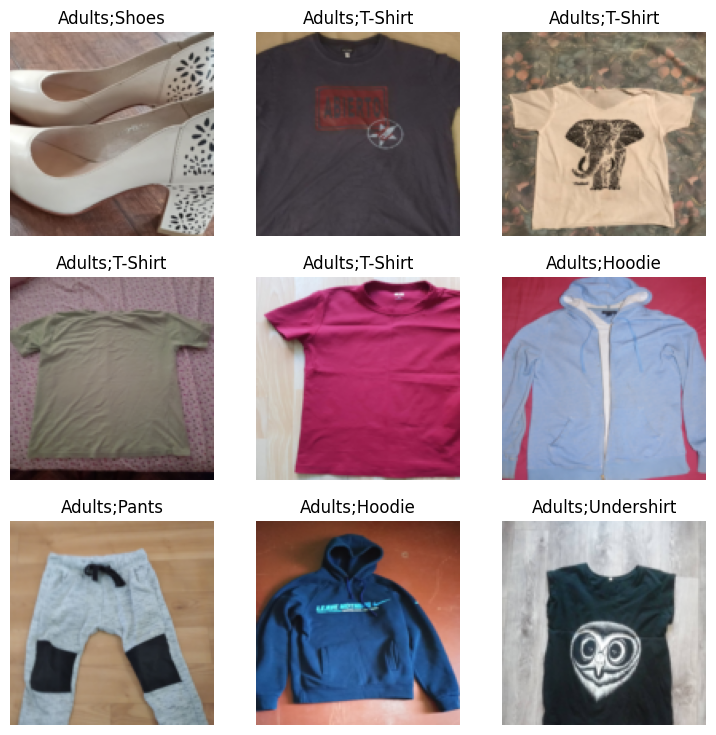

In [ ]:
path = '/content/clothing-dataset-full'

def get_x(r): return path + '/images_original/' + r['image']
def get_y(r): return r['label_cat'].split(' ')

dblock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_x=get_x,
    get_y=get_y,
    item_tfms=RandomResizedCrop(128, min_scale=0.35)
)

dls = dblock.dataloaders(label_df)
dls.show_batch(nrows=3, ncols=3)

## 5. Train the Model

In [ ]:
learn = cnn_learner(dls, resnet18, metrics=partial(accuracy_multi, thresh=0.2))
learn.fine_tune(8, base_lr=3e-3)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.795783,0.339474,0.491162,08:21


epoch,train_loss,valid_loss,accuracy_multi,time
0,0.336933,0.192610,0.845328,07:55
1,0.210827,0.122284,0.951810,07:51
2,0.145351,0.101156,0.958333,07:47
3,0.110246,0.089577,0.963805,07:48
4,0.092374,0.084834,0.966330,07:58
5,0.078525,0.082580,0.966625,07:57
6,0.070256,0.081343,0.966835,07:55
7,0.065282,0.081324,0.966709,07:49


## 6. Find Best Threshold

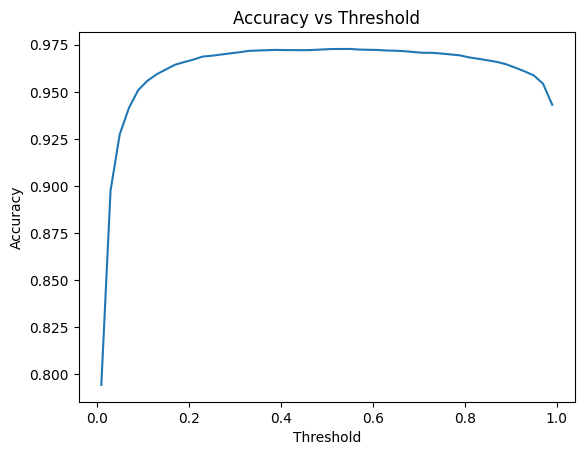

In [ ]:
preds, targs = learn.get_preds()

xs = torch.linspace(0.01, 0.99, 50)
accs = [accuracy_multi(preds, targs, thresh=i, sigmoid=False) for i in xs]
plt.plot(xs, accs)
plt.xlabel('Threshold')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Threshold')
plt.show()

## 7. Export Model

In [ ]:
# Save to Google Drive for reuse
save_path = '/content/drive/MyDrive/export.pkl'
learn.export(save_path)
print(f"Model saved to: {save_path}")

Model saved to: /content/drive/MyDrive/export.pkl


## 8. Predict on Image

In [ ]:
# Load model (run this cell alone if you already have export.pkl)
learn_inf = load_learner('/content/drive/MyDrive/export.pkl')
print("Model loaded! Vocab:", learn_inf.dls.vocab)

Model loaded! Vocab: ['Adults', 'Blazer', 'Blouse', 'Body', 'Dress', 'Hat', 'Hoodie', 'Kids', 'Longsleeve', 'Not_sure', 'Other', 'Outwear', 'Pants', 'Polo', 'Shirt', 'Shoes', 'Shorts', 'Skip', 'Skirt', 'T-Shirt', 'Top', 'Undershirt']


/usr/local/lib/python3.12/dist-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Upload a clothing image:


Saving photo_2026-05-21_16-43-16.jpg to photo_2026-05-21_16-43-16 (2).jpg


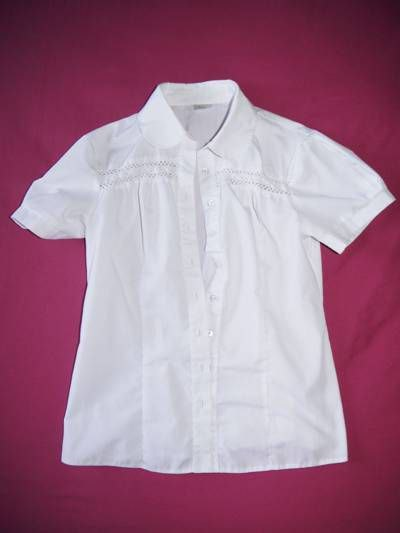


 Prediction: Shirt for Adults

Top 5 predictions:
  Shirt           38.2%
  T-Shirt         23.3%
  Polo            15.2%
  Dress           1.1%
  Not_sure        0.9%


In [ ]:
from google.colab import files
from fastai.vision.all import PILImage
from IPython.display import display, Image as IPImage

print("Upload a clothing image:")
uploaded = files.upload()

for filename, data in uploaded.items():
    with open(filename, 'wb') as f:
        f.write(data)

    display(IPImage(filename, width=256))

    img = PILImage.create(filename)
    pred, pred_idx, probs = learn_inf.predict(img)

    all_labels = learn_inf.dls.vocab


    age_labels      = ['Kids', 'Adults']
    clothing_labels = [l for l in all_labels if l not in age_labels]


    clothing_probs = {l: probs[list(all_labels).index(l)] for l in clothing_labels}
    best_clothing  = max(clothing_probs, key=clothing_probs.get)


    kids_prob   = probs[list(all_labels).index('Kids')]
    adults_prob = probs[list(all_labels).index('Adults')]
    age = 'Kids' if kids_prob > adults_prob else 'Adults'


    top5 = sorted(clothing_probs.items(), key=lambda x: x[1], reverse=True)[:5]

    print(f"\n Prediction: {best_clothing} for {age}")
    print("\nTop 5 predictions:")
    for label, prob in top5:
        print(f"  {label:<15} {prob*100:.1f}%")